In [1]:
#!wget https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/bv2hvm4pmz-3.zip
#!unzip /content/bv2hvm4pmz-3.zip

--2024-11-23 11:25:32--  https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/bv2hvm4pmz-3.zip
Resolving prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)... 52.218.1.168, 52.218.62.144, 3.5.69.18, ...
Connecting to prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)|52.218.1.168|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1340049458 (1.2G) [application/zip]
Saving to: ‘bv2hvm4pmz-3.zip’

bv2hvm4pmz-3.zip    100%[===================>]   1.25G  72.7MB/s    in 20s     

2024-11-23 11:25:52 (65.4 MB/s) - ‘bv2hvm4pmz-3.zip’ saved [1340049458/1340049458]

Archive:  /content/bv2hvm4pmz-3.zip
  inflating: Indoor Air Quality Monitoring @ Brindisi Airport/complete_measure_node_airport_gold.csv  
  inflating: Indoor Air Quality Monitoring @ Brindisi Airport/complete_measure_node_airport_silver.csv  
  inflating:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/Indoor Air Quality Monitoring @ Brindisi Airport/complete_measure_node_airport_gold.csv")

df

,id_measure;node_id;ads1115_value;ads1115_voltage;scd30_co2;scd30_temp;scd30_hum;sps30_pm05_count;sps30_pm1_count;sps30_pm1_ug;sps30_pm25_count;sps30_pm25_ug;sps30_pm4_count;sps30_pm4_ug;sps30_pm10_count;sps30_pm10_ug;sps30_pm_typ;ts_insertion
0,1;node-air-gold;1950;0.243757;606.316;29.3313;...
1,2;node-air-gold;1997;0.249633;605.303;29.3019;...
2,3;node-air-gold;1997;0.249633;605.58;29.3153;5...
3,4;node-air-gold;1977;0.247133;605.191;29.3153;...
4,5;node-air-gold;1957;0.244632;603.975;29.3019;...
...,...
7105446,7490026;node-air-gold;1663;0.207881;713.675;28...
7105447,7490027;node-air-gold;1664;0.208006;713.536;28...
7105448,7490028;node-air-gold;1645;0.205631;713.131;28...
7105449,7490029;node-air-gold;1664;0.207881;711.359;28...


In [2]:
df = pd.read_csv("/content/Indoor Air Quality Monitoring @ Brindisi Airport/complete_measure_node_airport_gold.csv", delimiter=';')

df

,id_measure,node_id,ads1115_value,ads1115_voltage,scd30_co2,scd30_temp,scd30_hum,sps30_pm05_count,sps30_pm1_count,sps30_pm1_ug,sps30_pm25_count,sps30_pm25_ug,sps30_pm4_count,sps30_pm4_ug,sps30_pm10_count,sps30_pm10_ug,sps30_pm_typ,ts_insertion
0,1,node-air-gold,1950,0.243757,606.316,29.3313,51.7258,26.4676,31.5050,3.97163,31.6969,4.19985,31.7065,4.19985,31.7126,4.19985,0.553393,2022-10-27 10:55:14
1,2,node-air-gold,1997,0.249633,605.303,29.3019,51.6693,26.3993,31.4237,3.96138,31.6152,4.18902,31.6247,4.18902,31.6308,4.18902,0.549469,2022-10-27 10:55:16
2,3,node-air-gold,1997,0.249633,605.580,29.3153,51.6327,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:18
3,4,node-air-gold,1977,0.247133,605.191,29.3153,51.7242,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:20
4,5,node-air-gold,1957,0.244632,603.975,29.3019,51.6556,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7105446,7490026,node-air-gold,1663,0.207881,713.675,28.1483,43.4067,38.6570,46.0142,5.80072,46.2946,6.13404,46.3085,6.13405,46.3175,6.13405,0.540815,2023-10-13 08:04:12
7105447,7490027,node-air-gold,1664,0.208006,713.536,28.1483,43.3792,39.3510,46.8404,5.90487,47.1258,6.24418,47.1399,6.24418,47.1491,6.24418,0.540534,2023-10-13 08:04:14
7105448,7490028,node-air-gold,1645,0.205631,713.131,28.1617,43.3243,39.4641,46.9749,5.92183,47.2612,6.26211,47.2754,6.26212,47.2845,6.26212,0.544188,2023-10-13 08:04:17
7105449,7490029,node-air-gold,1664,0.207881,711.359,28.1617,43.3655,39.8152,47.3929,5.97452,47.6817,6.31783,47.6960,6.31783,47.7052,6.31783,0.543882,2023-10-13 08:04:19


In [3]:
print(df.isnull().sum()) #checking for NULL values in the dataset

id_measure           0
node_id              0
ads1115_value        0
ads1115_voltage      0
scd30_co2            0
scd30_temp           0
scd30_hum            0
sps30_pm05_count    12
sps30_pm1_count     15
sps30_pm1_ug         0
sps30_pm25_count    17
sps30_pm25_ug        8
sps30_pm4_count     23
sps30_pm4_ug         9
sps30_pm10_count    23
sps30_pm10_ug       11
sps30_pm_typ        25
ts_insertion         0
dtype: int64


In [4]:
#Turning null values into 0's
columns_to_fill = [
    'sps30_pm05_count', 'sps30_pm1_count', 'sps30_pm25_count', 'sps30_pm4_count',
    'sps30_pm10_count', 'sps30_pm_typ', 'sps30_pm25_ug', 'sps30_pm4_ug', 'sps30_pm10_ug'
]

df[columns_to_fill] = df[columns_to_fill].fillna(0)

print(df.isnull().sum())

id_measure          0
node_id             0
ads1115_value       0
ads1115_voltage     0
scd30_co2           0
scd30_temp          0
scd30_hum           0
sps30_pm05_count    0
sps30_pm1_count     0
sps30_pm1_ug        0
sps30_pm25_count    0
sps30_pm25_ug       0
sps30_pm4_count     0
sps30_pm4_ug        0
sps30_pm10_count    0
sps30_pm10_ug       0
sps30_pm_typ        0
ts_insertion        0
dtype: int64


In [5]:
cols_to_drop=['id_measure','node_id']

df = df.drop(columns=df.filter(items=cols_to_drop).columns)

df

,ads1115_value,ads1115_voltage,scd30_co2,scd30_temp,scd30_hum,sps30_pm05_count,sps30_pm1_count,sps30_pm1_ug,sps30_pm25_count,sps30_pm25_ug,sps30_pm4_count,sps30_pm4_ug,sps30_pm10_count,sps30_pm10_ug,sps30_pm_typ,ts_insertion
0,1950,0.243757,606.316,29.3313,51.7258,26.4676,31.5050,3.97163,31.6969,4.19985,31.7065,4.19985,31.7126,4.19985,0.553393,2022-10-27 10:55:14
1,1997,0.249633,605.303,29.3019,51.6693,26.3993,31.4237,3.96138,31.6152,4.18902,31.6247,4.18902,31.6308,4.18902,0.549469,2022-10-27 10:55:16
2,1997,0.249633,605.580,29.3153,51.6327,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:18
3,1977,0.247133,605.191,29.3153,51.7242,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:20
4,1957,0.244632,603.975,29.3019,51.6556,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7105446,1663,0.207881,713.675,28.1483,43.4067,38.6570,46.0142,5.80072,46.2946,6.13404,46.3085,6.13405,46.3175,6.13405,0.540815,2023-10-13 08:04:12
7105447,1664,0.208006,713.536,28.1483,43.3792,39.3510,46.8404,5.90487,47.1258,6.24418,47.1399,6.24418,47.1491,6.24418,0.540534,2023-10-13 08:04:14
7105448,1645,0.205631,713.131,28.1617,43.3243,39.4641,46.9749,5.92183,47.2612,6.26211,47.2754,6.26212,47.2845,6.26212,0.544188,2023-10-13 08:04:17
7105449,1664,0.207881,711.359,28.1617,43.3655,39.8152,47.3929,5.97452,47.6817,6.31783,47.6960,6.31783,47.7052,6.31783,0.543882,2023-10-13 08:04:19


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105451 entries, 0 to 7105450
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   ads1115_value     int64  
 1   ads1115_voltage   float64
 2   scd30_co2         float64
 3   scd30_temp        float64
 4   scd30_hum         float64
 5   sps30_pm05_count  float64
 6   sps30_pm1_count   float64
 7   sps30_pm1_ug      float64
 8   sps30_pm25_count  float64
 9   sps30_pm25_ug     float64
 10  sps30_pm4_count   float64
 11  sps30_pm4_ug      float64
 12  sps30_pm10_count  float64
 13  sps30_pm10_ug     float64
 14  sps30_pm_typ      float64
 15  ts_insertion      object 
dtypes: float64(14), int64(1), object(1)
memory usage: 867.4+ MB


In [7]:
df['ts_insertion'] = pd.to_datetime(df['ts_insertion'])

int_cols = df.select_dtypes(include=['int64']).columns
df[int_cols] = df[int_cols].astype('float64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105451 entries, 0 to 7105450
Data columns (total 16 columns):
 #   Column            Dtype         
---  ------            -----         
 0   ads1115_value     float64       
 1   ads1115_voltage   float64       
 2   scd30_co2         float64       
 3   scd30_temp        float64       
 4   scd30_hum         float64       
 5   sps30_pm05_count  float64       
 6   sps30_pm1_count   float64       
 7   sps30_pm1_ug      float64       
 8   sps30_pm25_count  float64       
 9   sps30_pm25_ug     float64       
 10  sps30_pm4_count   float64       
 11  sps30_pm4_ug      float64       
 12  sps30_pm10_count  float64       
 13  sps30_pm10_ug     float64       
 14  sps30_pm_typ      float64       
 15  ts_insertion      datetime64[ns]
dtypes: datetime64[ns](1), float64(15)
memory usage: 867.4 MB


In [8]:
df2 = df.head(6000000)

In [9]:
filtered_data_after_sep = df[df['ts_insertion'] > '2023-09-30']

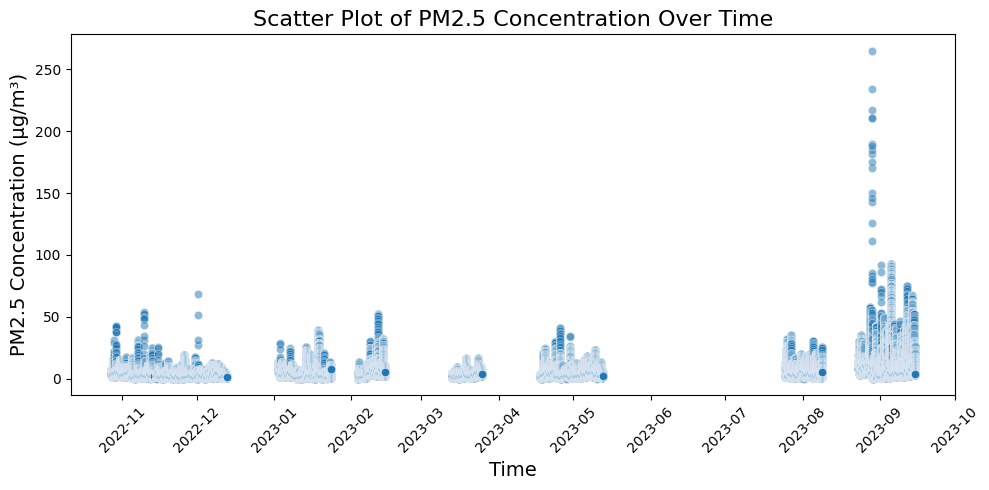

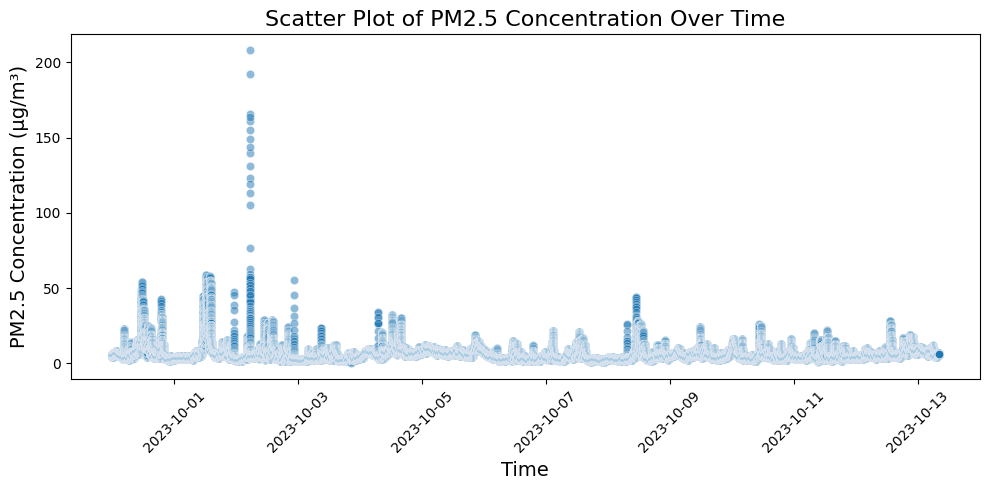

In [10]:

plt.figure(figsize=(10, 5))
sns.scatterplot(x='ts_insertion', y='sps30_pm25_ug', data=df2, alpha=0.5)

plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14)
plt.title('Scatter Plot of PM2.5 Concentration Over Time', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.scatterplot(x='ts_insertion', y='sps30_pm25_ug', data=filtered_data_after_sep, alpha=0.5)

plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14)
plt.title('Scatter Plot of PM2.5 Concentration Over Time', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
df.describe()

,ads1115_value,ads1115_voltage,scd30_co2,scd30_temp,scd30_hum,sps30_pm05_count,sps30_pm1_count,sps30_pm1_ug,sps30_pm25_count,sps30_pm25_ug,sps30_pm4_count,sps30_pm4_ug,sps30_pm10_count,sps30_pm10_ug,sps30_pm_typ,ts_insertion
count,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7.105451e+06,7105451
mean,1.652306e+03,2.065447e-01,6.562494e+02,2.863171e+01,3.879722e+01,9.558714e+31,9.484918e+31,3.632853e+00,2.378659e+32,4.779640e+31,2.852940e+32,9.558997e+31,3.330890e+32,9.558714e+31,3.323510e+32,2023-04-16 13:55:47.442002688
min,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.005880e+34,-2.616750e+36,1.836700e-40,-2.616750e+36,0.000000e+00,-2.616750e+36,-1.005880e+34,-2.616750e+36,-1.005880e+34,-2.616750e+36,2022-10-27 10:55:14
25%,1.514000e+03,1.892560e-01,5.640120e+02,2.776910e+01,3.314670e+01,1.095580e+01,1.309490e+01,1.654640e+00,1.320360e+01,1.774360e+00,1.321230e+01,1.790150e+00,1.321550e+01,1.792720e+00,4.866950e-01,2022-12-12 13:57:45
50%,1.640000e+03,2.050060e-01,6.113940e+02,2.893870e+01,4.030460e+01,1.876020e+01,2.240190e+01,2.828590e+00,2.257250e+01,3.014150e+00,2.258460e+01,3.030490e+00,2.258980e+01,3.033730e+00,5.072100e-01,2023-04-18 03:17:28
75%,1.770000e+03,2.212570e-01,7.140700e+02,2.971050e+01,4.607540e+01,2.994330e+01,3.571570e+01,4.506590e+00,3.596420e+01,4.813050e+00,3.598080e+01,4.837410e+00,3.598860e+01,4.841445e+00,5.330795e-01,2023-08-29 00:13:54
max,3.276700e+04,1.192040e+00,1.840010e+03,3.353440e+01,5.831600e+01,3.396150e+38,3.396150e+38,2.504980e+02,3.396150e+38,3.396150e+38,3.396150e+38,3.396150e+38,3.396150e+38,3.396150e+38,3.396150e+38,2023-10-13 08:04:21
std,2.271290e+02,2.835373e-02,1.402297e+02,2.224686e+00,9.134442e+00,1.801798e+35,1.801851e+35,3.431872e+00,2.848942e+35,1.274063e+35,3.120866e+35,1.801798e+35,3.370911e+35,1.801798e+35,3.370939e+35,NaN


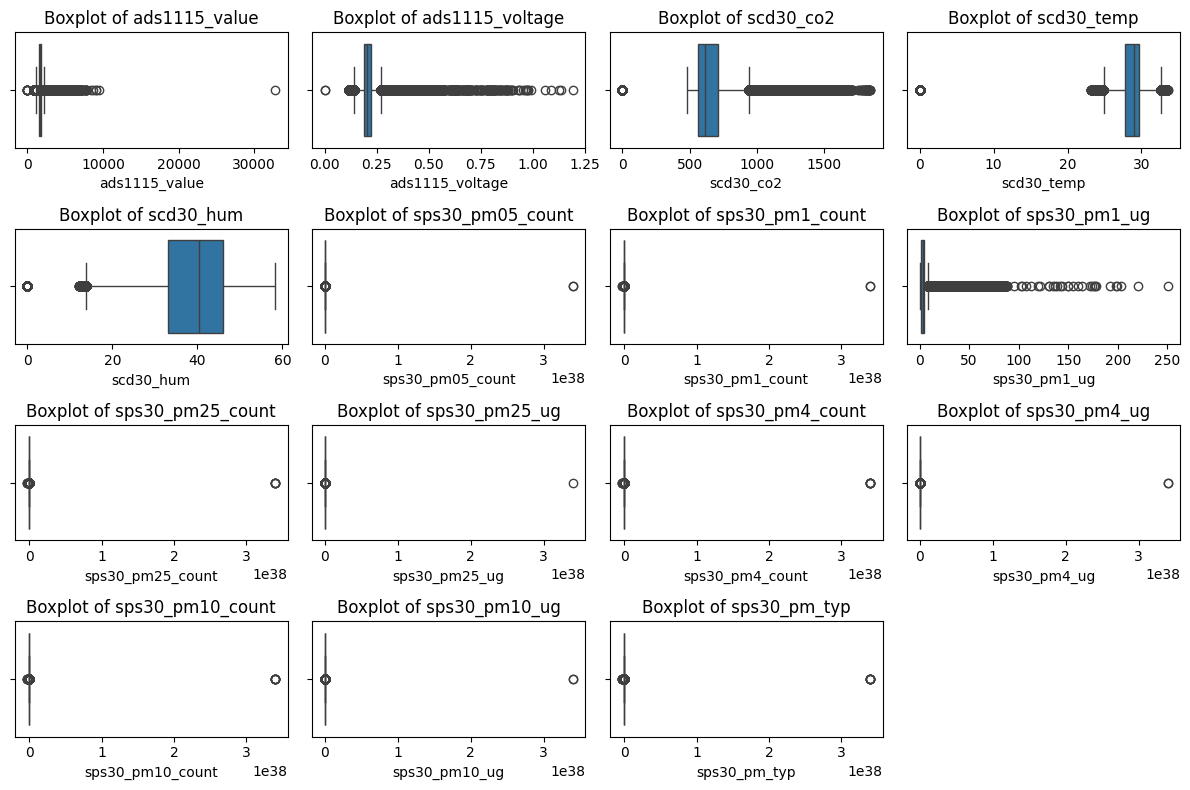

In [10]:
plt.figure(figsize=(12, 8))
numeric_cols = df2.select_dtypes(include=['float64', 'int64']).columns  # Select only numeric columns

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)  # Create subplots for each column
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [14]:
'''from sklearn.preprocessing import QuantileTransformer
cols = ["sps30_pm05_count", "sps30_pm1_count", "sps30_pm25_count","sps30_pm25_ug", "sps30_pm4_count", "sps30_pm4_ug","sps30_pm25_ug","sps30_pm10_count","sps30_pm10_ug","sps30_pm_typ"]
transformed_data = df.copy()
#log tranform for handling extreme values
for col in cols:
    transformed_data[col] = np.log10(transformed_data[col] + 1)

print(transformed_data.describe())
print(transformed_data)

/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


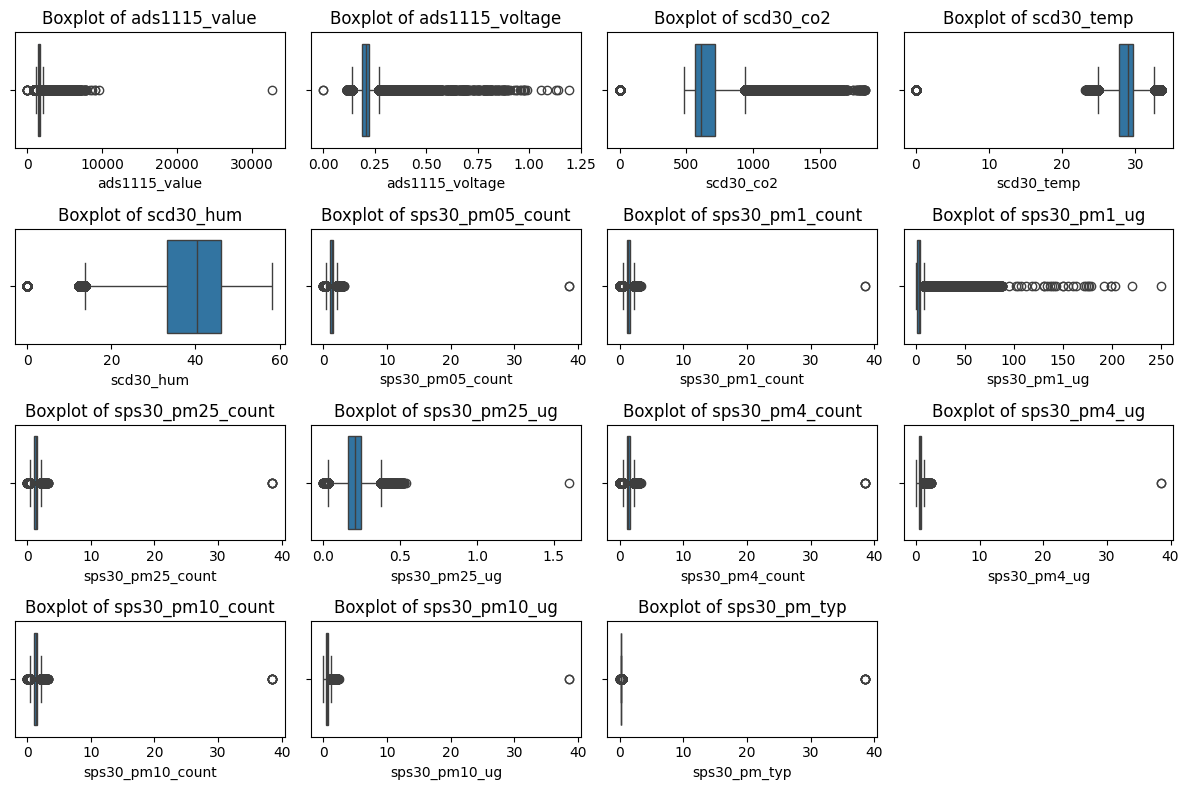

In [17]:
#boxplots after log transform
'''
plt.figure(figsize=(12, 8))
numeric_cols = transformed_data.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data=transformed_data, x=col)
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [18]:
#clipping for determining upperbound
'''clipped_data = transformed_data.copy()
max_value = 4


for col in cols:
    if col in ["sps30_pm05_count", "sps30_pm1_count", "sps30_pm25_count",
               "sps30_pm4_count", "sps30_pm4_ug", "sps30_pm25_ug",
               "sps30_pm10_count", "sps30_pm10_ug"]:
        clipped_data[col] = clipped_data[col].clip(upper=max_value)


clipped_data["sps30_pm_typ"] = clipped_data["sps30_pm_typ"].clip(upper=0.5)#0.5 is upperbound for sps30_pm_typ column


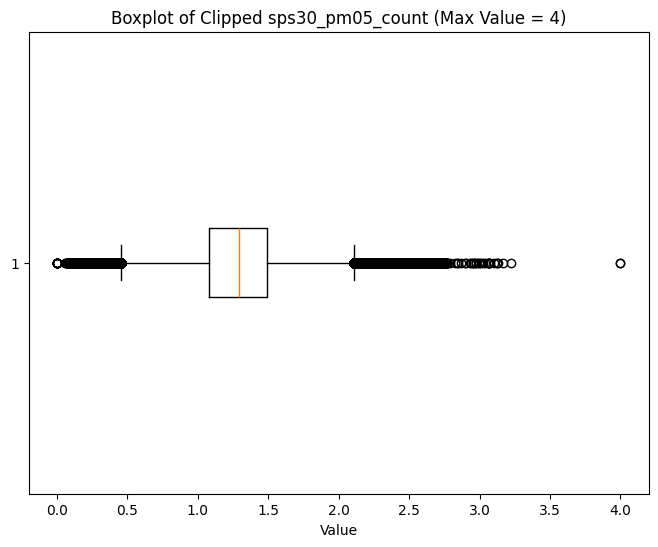

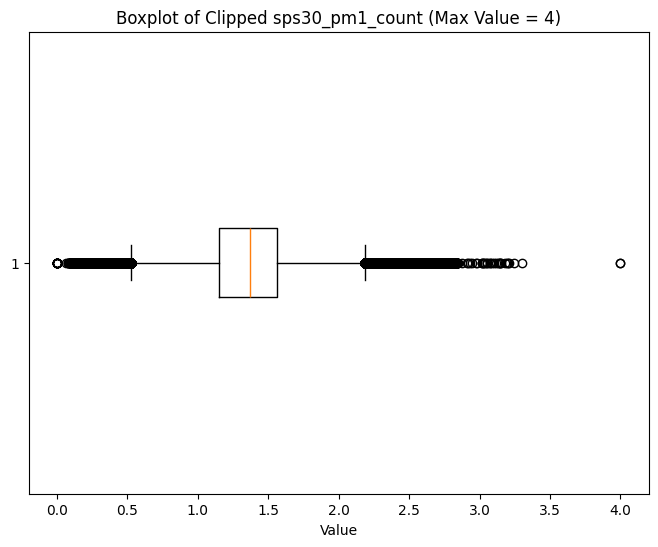

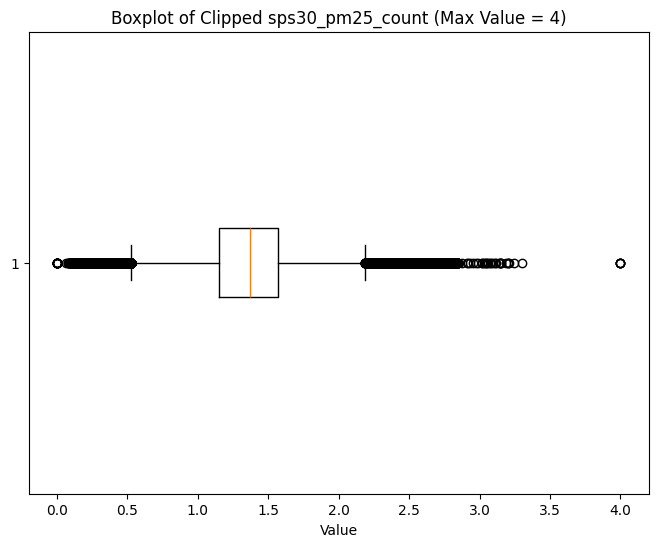

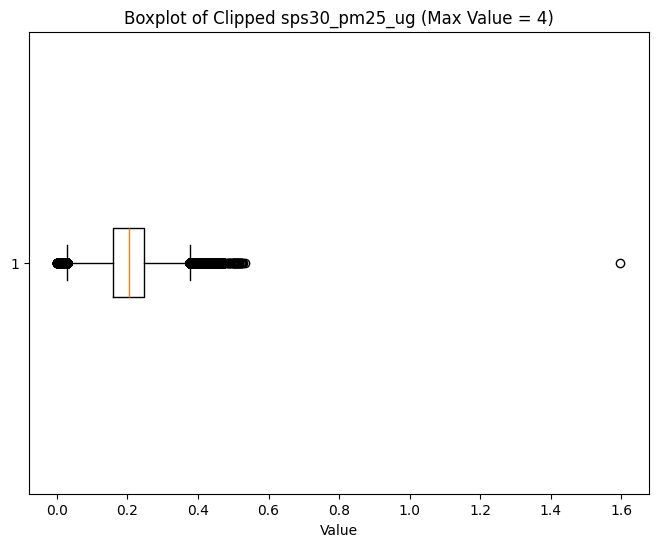

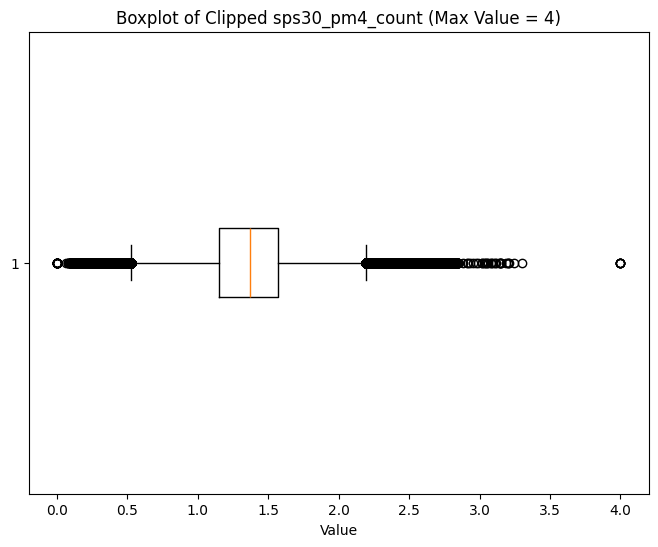

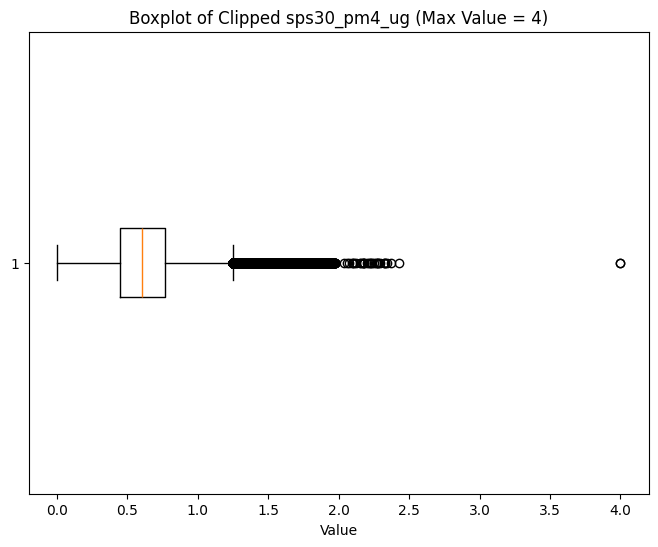

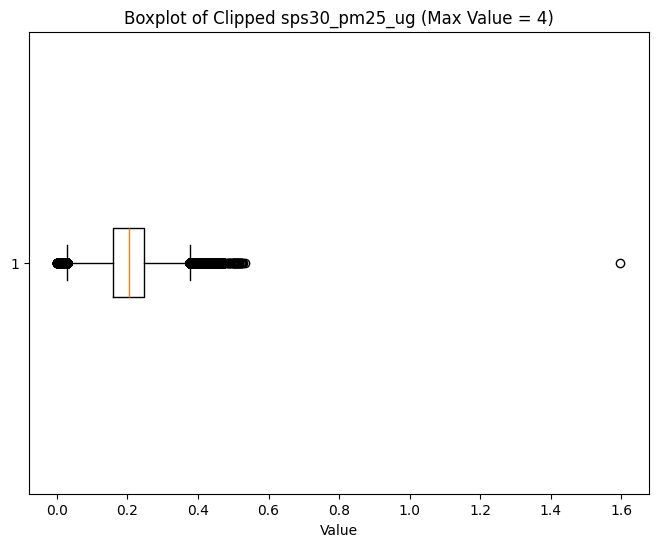

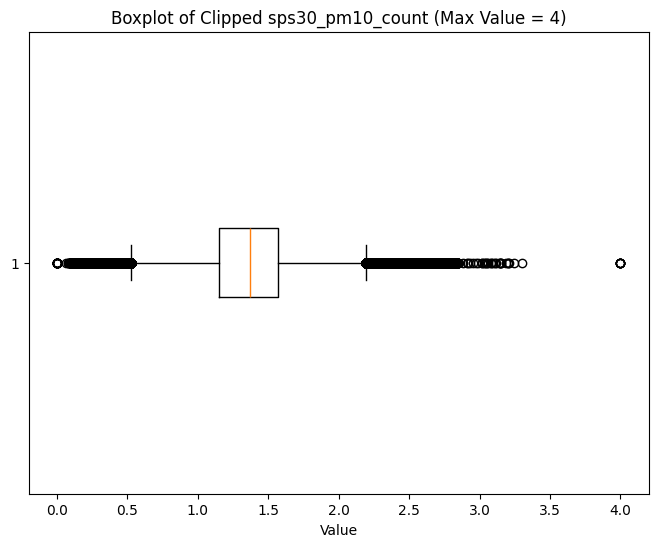

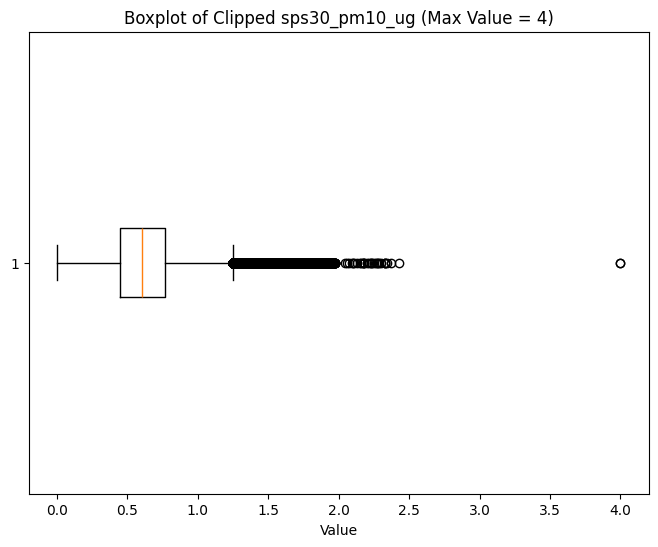

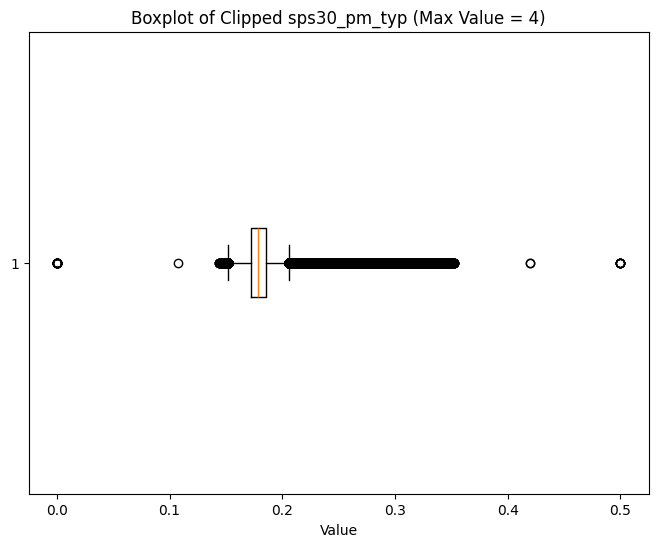

In [19]:
#boxplots after clipping
'''for col in cols:
    plt.figure(figsize=(8, 6))
    plt.boxplot(clipped_data[col].dropna(), vert=False)
    plt.title(f'Boxplot of Clipped {col} (Max Value = {max_value})')
    plt.xlabel('Value')
    plt.show()

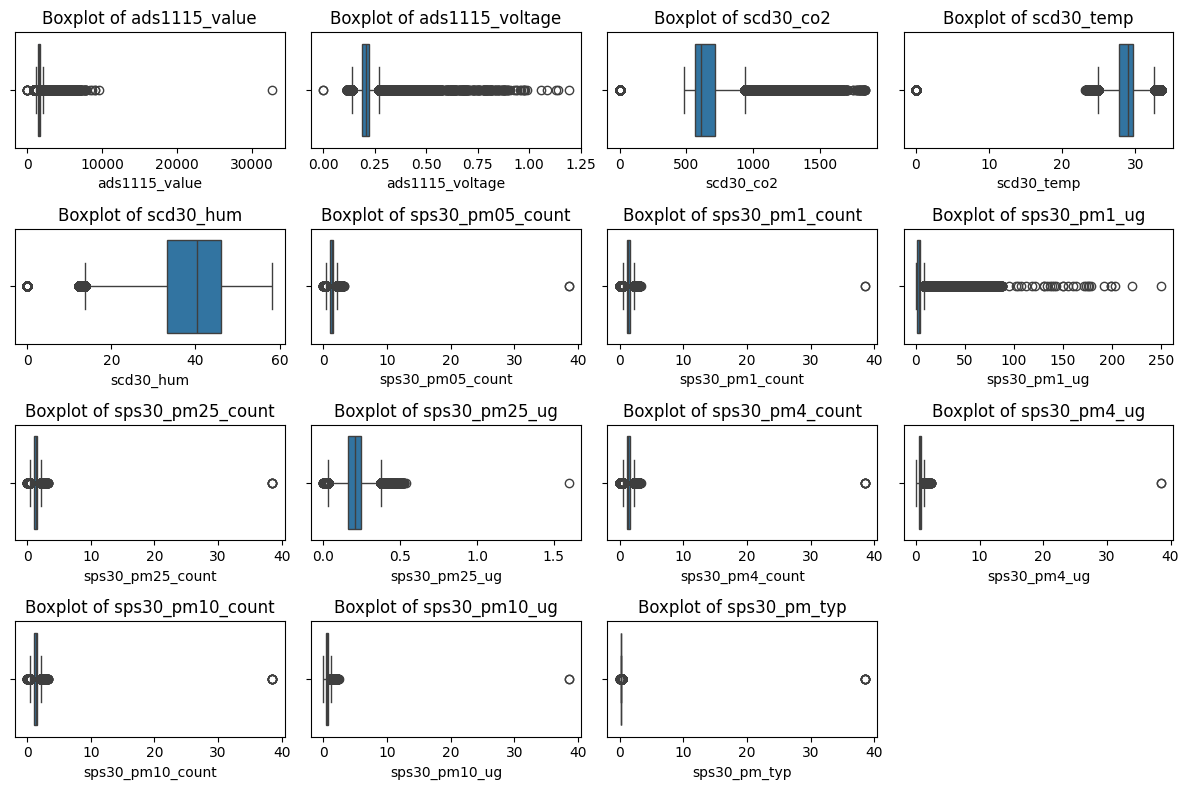

In [31]:
#boxplots for entire dataset after log transform and clipping
'''plt.figure(figsize=(12, 8))
numeric_cols = clipped_data.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data=transformed_data, x=col)
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [21]:
'''for col in numeric_cols:
    plt.figure(figsize=(8, 4))

    # Violin plot
    plt.subplot(1, 2, 1)
    sns.violinplot(data=clipped_data, x=col, cut=0)  # `cut=0` prevents extending beyond data range
    plt.title(f'Violin Plot of {col}')

    # Histogram
    plt.subplot(1, 2, 2)
    sns.histplot(data=clipped_data, x=col, kde=True, bins=30)
    plt.title(f'Histogram of {col}')

    plt.tight_layout()
    plt.show()'''

"for col in numeric_cols:\n    plt.figure(figsize=(8, 4))\n\n    # Violin plot\n    plt.subplot(1, 2, 1)\n    sns.violinplot(data=clipped_data, x=col, cut=0)  # `cut=0` prevents extending beyond data range\n    plt.title(f'Violin Plot of {col}')\n\n    # Histogram\n    plt.subplot(1, 2, 2)\n    sns.histplot(data=clipped_data, x=col, kde=True, bins=30)\n    plt.title(f'Histogram of {col}')\n\n    plt.tight_layout()\n    plt.show()"

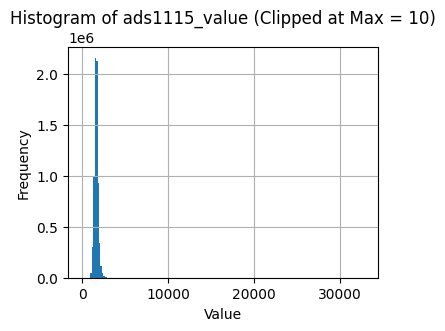

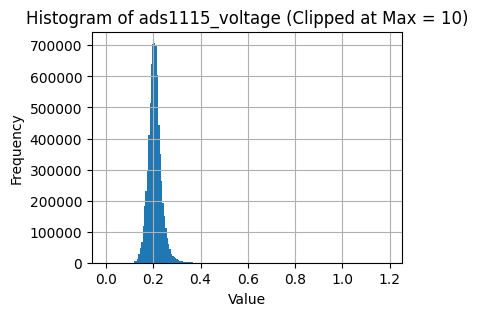

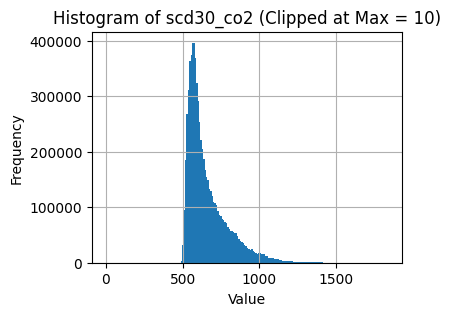

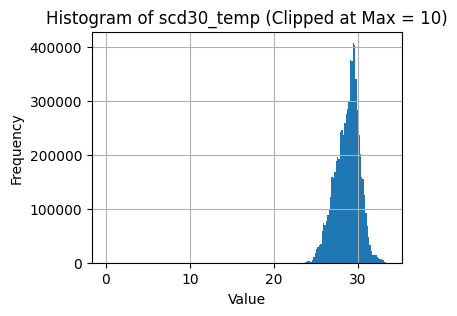

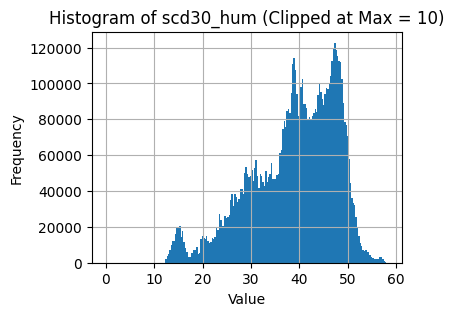

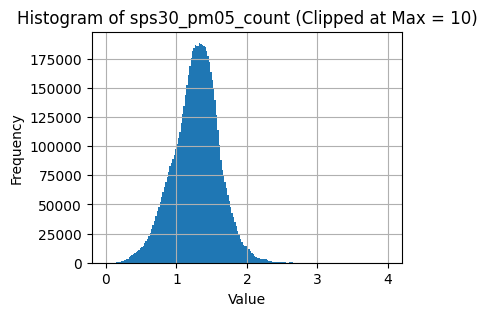

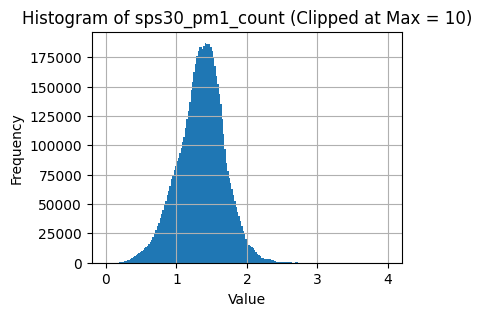

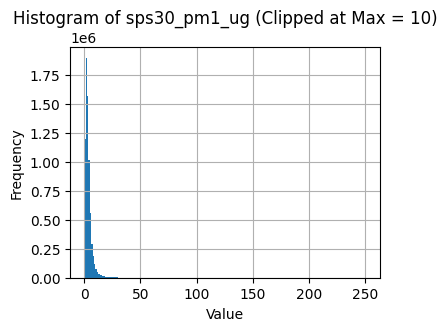

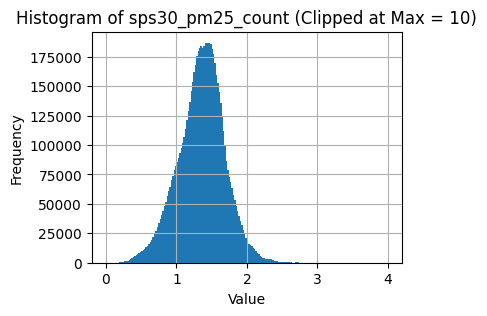

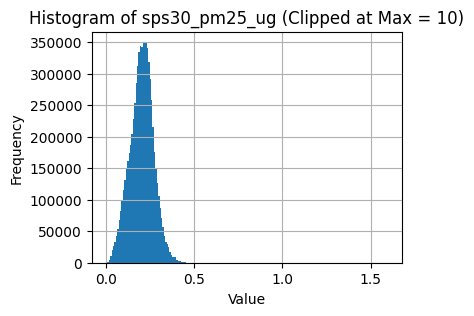

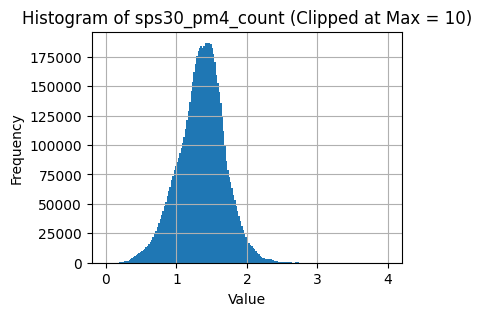

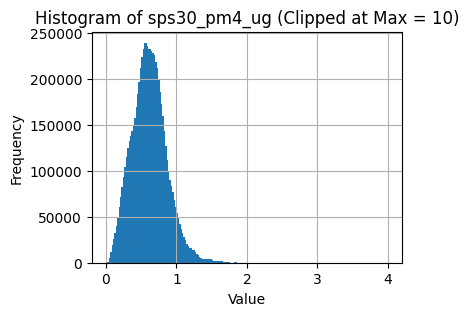

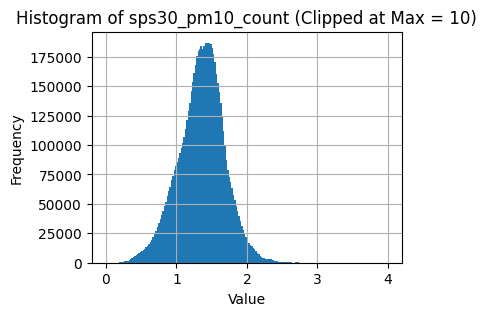

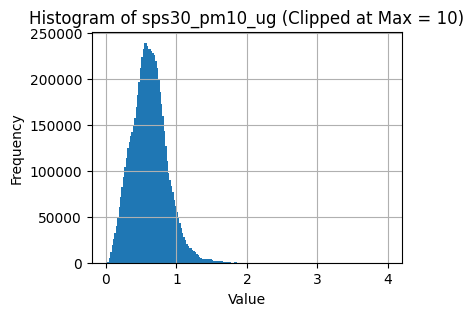

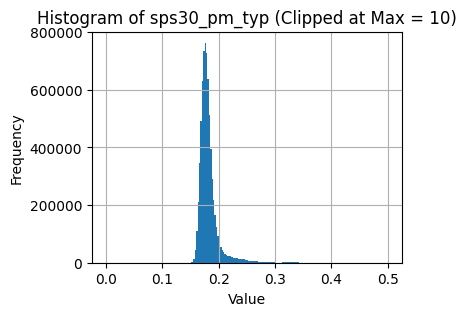

In [22]:
'''for col in numeric_cols:
    plt.figure(figsize=(4, 3))
    clipped_data[col].dropna().hist(bins=200)  # Histogram with 20 bins
    plt.title(f'Histogram of {col} (Clipped at Max = 10)')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

In [11]:
def handle_outliers_iqr(data, columns):
    data_cleaned = data.copy()
    for col in columns:
        Q1 = data_cleaned[col].quantile(0.25)  # First quartile (25%)
        Q3 = data_cleaned[col].quantile(0.75)  # Third quartile (75%)
        IQR = Q3 - Q1  # Interquartile range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Clip outliers outside the bounds
        data_cleaned[col] = data_cleaned[col].clip(lower=lower_bound, upper=upper_bound)
    return data_cleaned

In [12]:
'''from scipy.stats import zscore
def handle_outliers_zscore(data, columns, threshold=3.0):
    data_cleaned = data.copy()
    for col in columns:
        # Drop NaN to compute Z-scores properly
        valid_data = data_cleaned[col].dropna()
        # Calculate Z-scores for the column
        z_scores = zscore(valid_data)
        # Replace outliers with NaN if z-score exceeds the threshold
        outliers = abs(z_scores) > threshold
        # Assign NaN to outlier positions in the original column
        data_cleaned.loc[valid_data.index[outliers], col] = np.nan
    return data_cleaned

In [13]:
cleaned_data = handle_outliers_iqr(df, numeric_cols)
#zscore_cleaned_data = handle_outliers_zscore(df, numeric_cols)

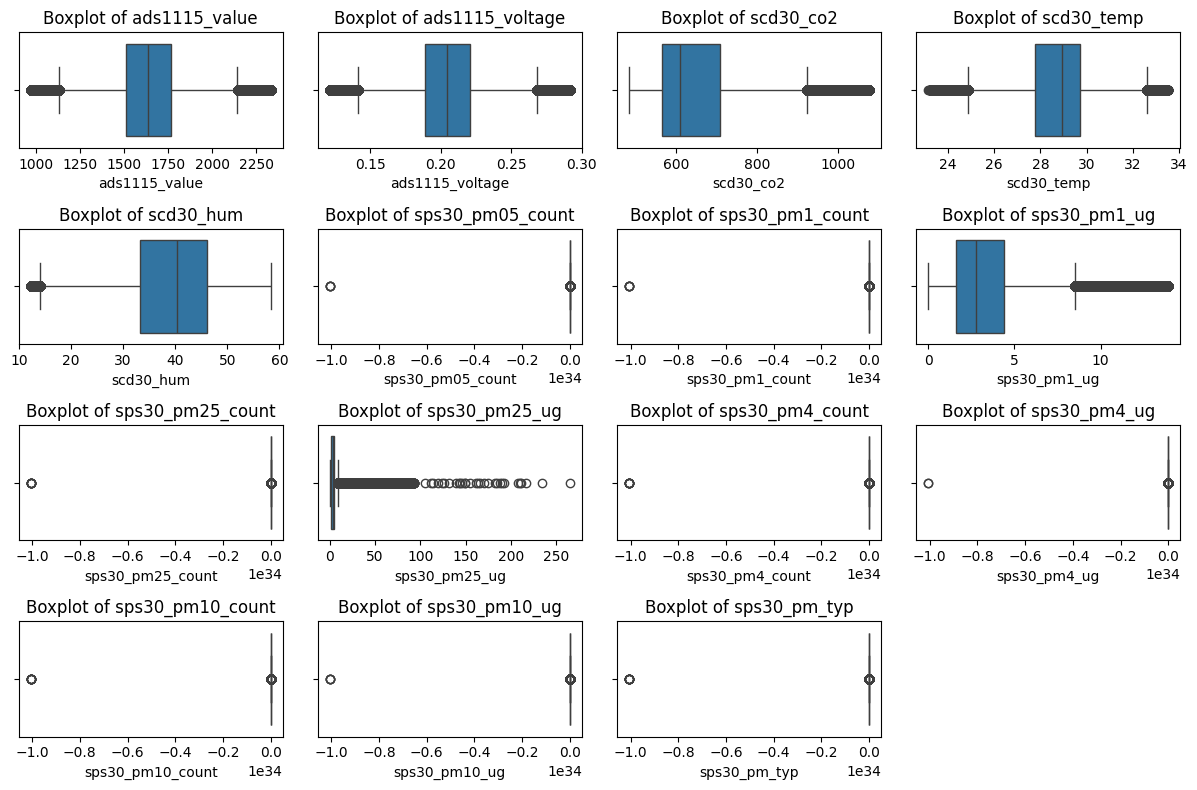

In [14]:
#x score plot
'''plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data=zscore_cleaned_data, x=col)
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

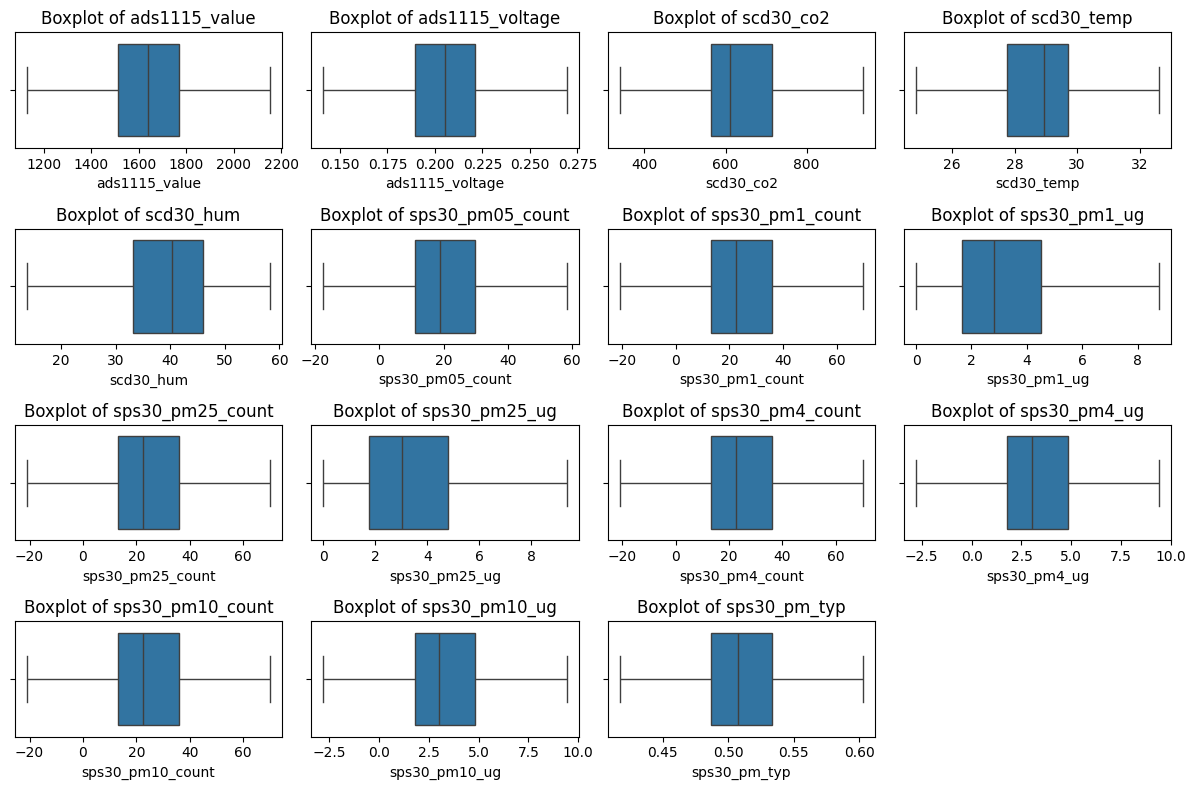

In [19]:
#boxplots after iqr
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data=cleaned_data, x=col)
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

<Axes: >

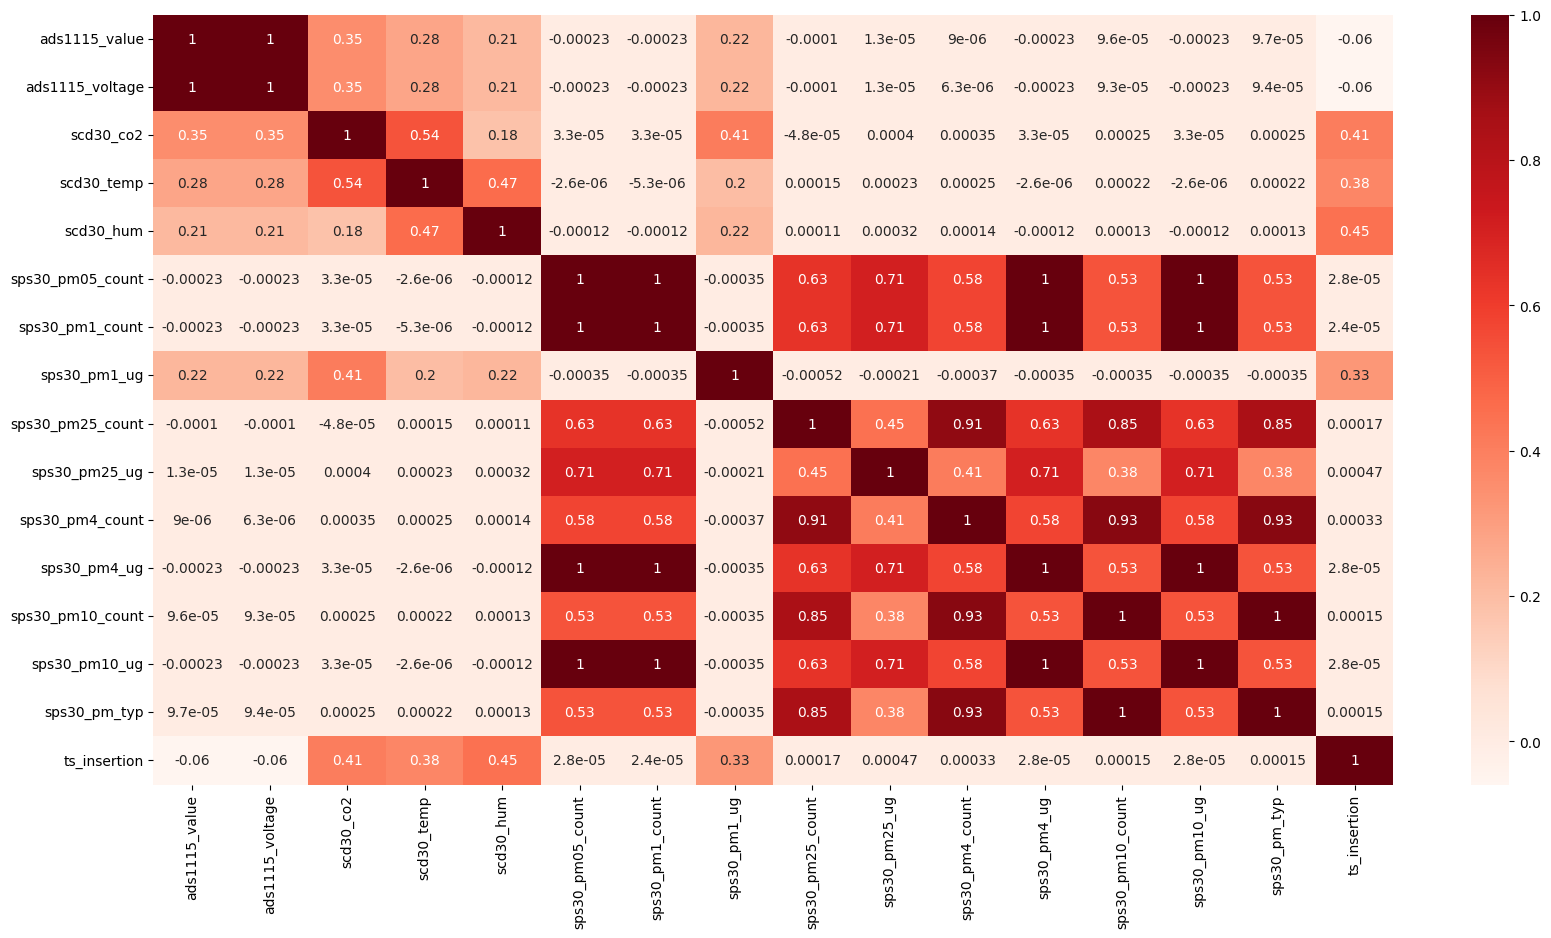

In [16]:
correlation_matrix = df[numeric_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(20, 10))
corr = df.corr()
sns.heatmap(corr, cmap="Reds", annot=True)

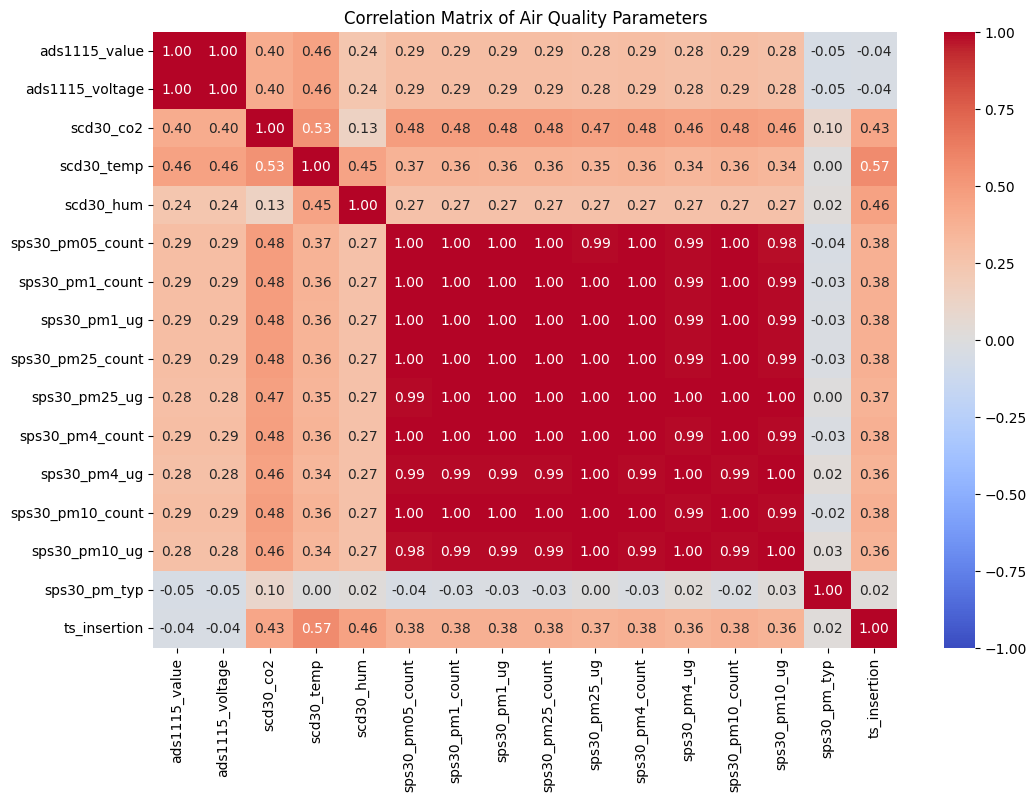

In [17]:
corr2 = cleaned_data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr2, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Air Quality Parameters')
plt.show()


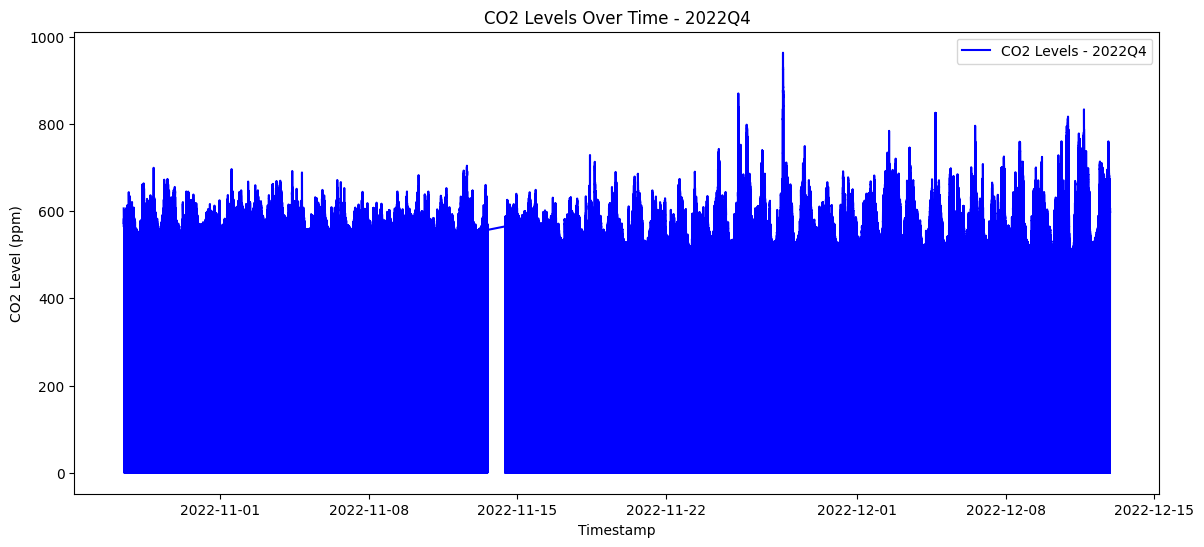

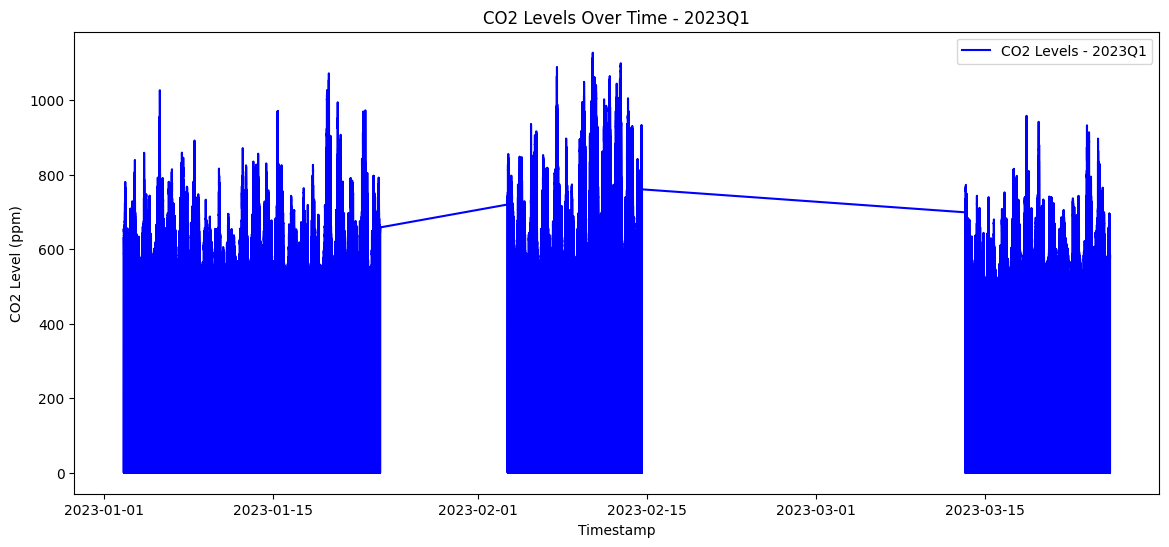

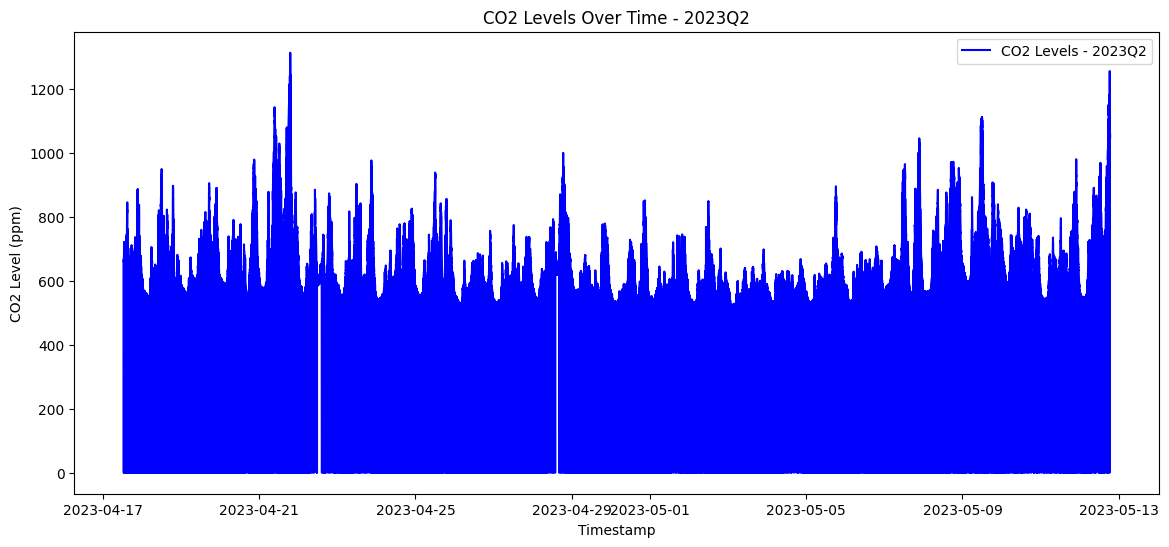

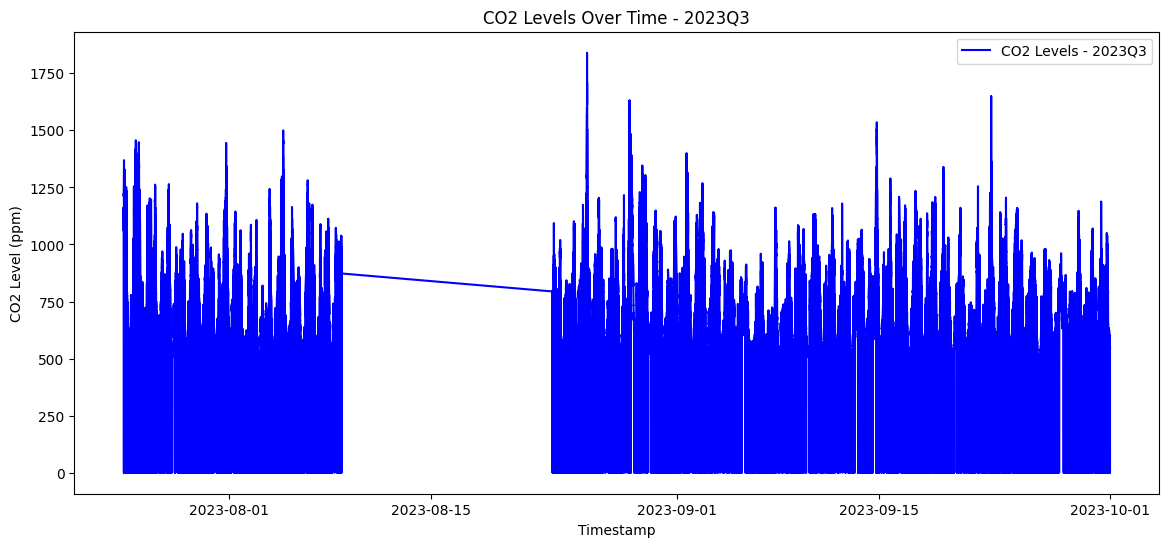

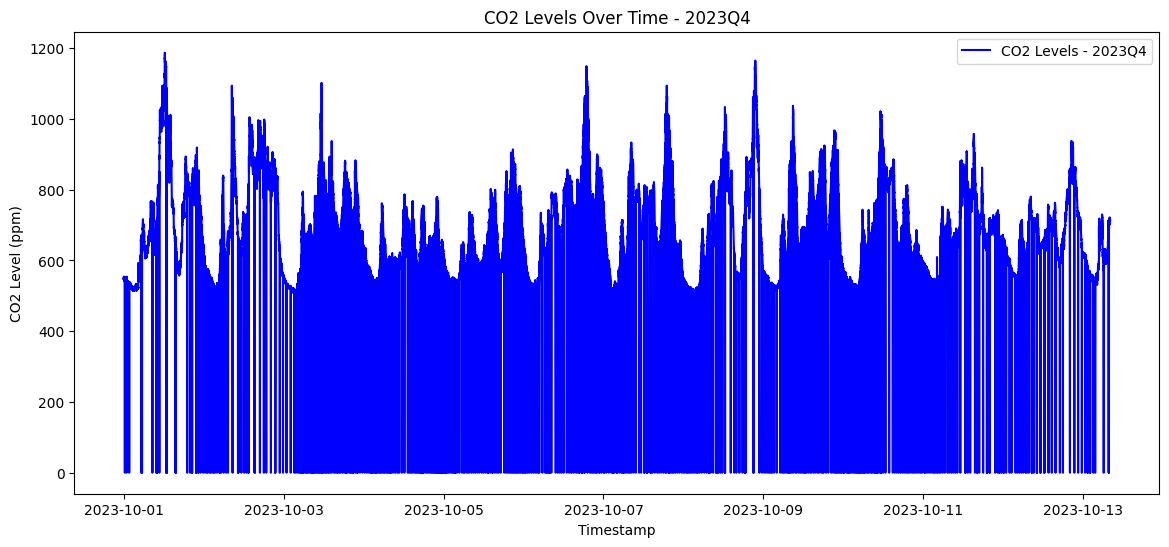

In [21]:
cleaned_data['ts_insertion'] = pd.to_datetime(cleaned_data['ts_insertion'])
df_sorted = df.sort_values('ts_insertion')
df_sorted['quarter'] = df_sorted['ts_insertion'].dt.to_period('Q')
unique_quarters = df_sorted['quarter'].unique()

for quarter in unique_quarters:
    quarter_data = df_sorted[df_sorted['quarter'] == quarter]
    plt.figure(figsize=(14, 6))
    plt.plot(quarter_data['ts_insertion'], quarter_data['scd30_co2'], label=f'CO2 Levels - {quarter}', color='blue')
    plt.xlabel('Timestamp')
    plt.ylabel('CO2 Level (ppm)')
    plt.title(f'CO2 Levels Over Time - {quarter}')
    plt.legend()
    plt.show()

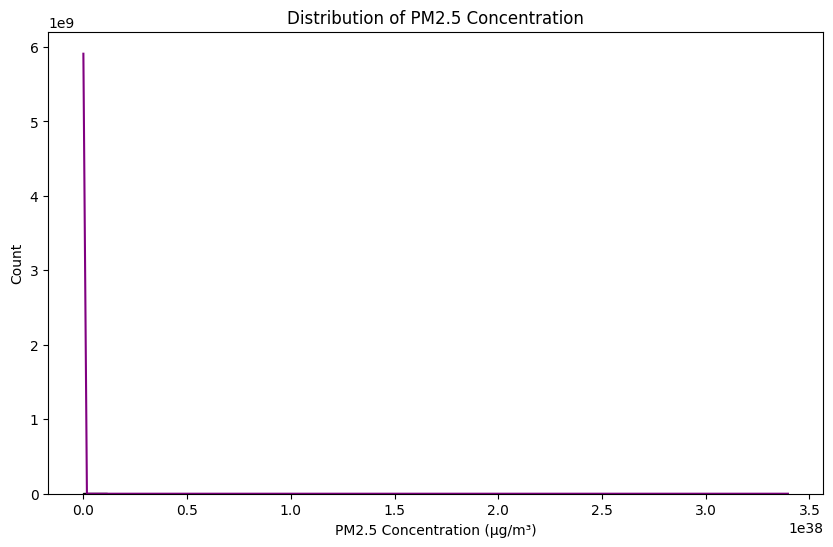

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_data['sps30_pm25_ug'], kde=True, bins=30, color='purple')
plt.xlabel('PM2.5 Concentration (µg/m³)')
plt.title('Distribution of PM2.5 Concentration')
plt.show()

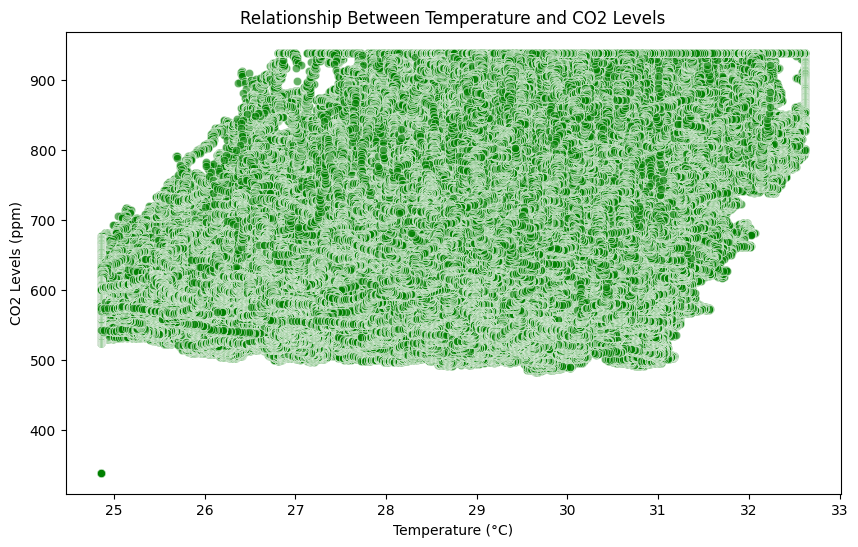

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='scd30_temp', y='scd30_co2', data=cleaned_data, color='green', alpha=0.6)
plt.xlabel('Temperature (°C)')
plt.ylabel('CO2 Levels (ppm)')
plt.title('Relationship Between Temperature and CO2 Levels')
plt.show()

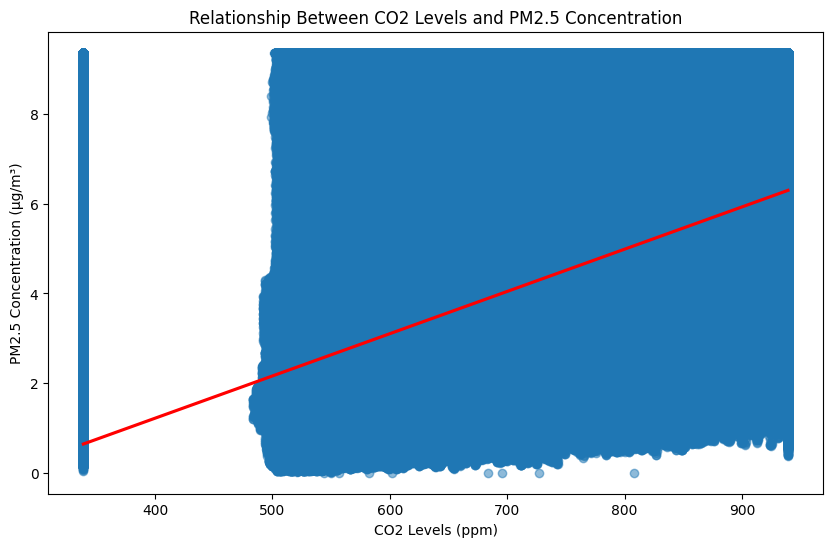

In [26]:
plt.figure(figsize=(10, 6))
sns.regplot(x='scd30_co2', y='sps30_pm25_ug', data=cleaned_data, scatter_kws={'alpha':0.5}, line_kws={"color":"red"})
plt.xlabel('CO2 Levels (ppm)')
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.title('Relationship Between CO2 Levels and PM2.5 Concentration')
plt.show()